In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
tickets = pd.read_csv("C://Users//Asus//Mahesh_Program//py//tickets.csv");
teams = pd.read_csv("C://Users//Asus//Mahesh_Program//py//teams.csv")

In [13]:
tickets.head()

,ticket_id,month,team_id,channel,resolution_hours,satisfaction
0,1,Jan,T1,Email,12,4
1,2,Jan,T2,Chat,28,3
2,3,Jan,T3,Phone,36,2
3,4,Jan,T4,Email,20,4
4,5,Feb,T1,Chat,8,5


In [11]:
teams.head()

,team_id,team,department
0,T1,AccountCare,Service
1,T2,BillingHelp,Service
2,T3,AppSupport,Technical
3,T4,DeviceHelp,Technical


In [17]:
tickets.isnull().sum()

ticket_id           0
month               0
team_id             0
channel             0
resolution_hours    0
satisfaction        0
dtype: int64

In [18]:
teams.isnull().sum()

team_id       0
team          0
department    0
dtype: int64

In [21]:
tickets = tickets.drop_duplicates().reset_index(drop=True)

# 2. Merge using LEFT JOIN
merged_df = tickets.merge(teams,
    on="team_id",
    how="left")

# 3. Assert exactly 12 rows
assert len(merged_df) == 12, "Merged DataFrame does not contain exactly 12 rows"


# Display result
print("Duplicate rows removed successfully.")
print("Merged rows:", len(merged_df))
print("Unmatched team_id:", merged_df["department"].isna().sum())

display(merged_df)

Duplicate rows removed successfully.
Merged rows: 12
Unmatched team_id: 0


,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department
0,1,Jan,T1,Email,12,4,AccountCare,Service
1,2,Jan,T2,Chat,28,3,BillingHelp,Service
2,3,Jan,T3,Phone,36,2,AppSupport,Technical
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical
4,5,Feb,T1,Chat,8,5,AccountCare,Service
5,6,Feb,T2,Phone,30,3,BillingHelp,Service
6,7,Feb,T3,Email,18,4,AppSupport,Technical
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical
8,9,Mar,T1,Phone,16,4,AccountCare,Service
9,10,Mar,T2,Email,22,4,BillingHelp,Service


# P2 — Derived Field & Department Analysis 

In [26]:
#Calculate breach_flag
merged_df["breach_flag"] = (merged_df["resolution_hours"] > 24).astype(int)
merged_df

,ticket_id,month,team_id,channel,resolution_hours,satisfaction,team,department,breach_flag
0,1,Jan,T1,Email,12,4,AccountCare,Service,0
1,2,Jan,T2,Chat,28,3,BillingHelp,Service,1
2,3,Jan,T3,Phone,36,2,AppSupport,Technical,1
3,4,Jan,T4,Email,20,4,DeviceHelp,Technical,0
4,5,Feb,T1,Chat,8,5,AccountCare,Service,0
5,6,Feb,T2,Phone,30,3,BillingHelp,Service,1
6,7,Feb,T3,Email,18,4,AppSupport,Technical,0
7,8,Feb,T4,Chat,40,2,DeviceHelp,Technical,1
8,9,Mar,T1,Phone,16,4,AccountCare,Service,0
9,10,Mar,T2,Email,22,4,BillingHelp,Service,0


In [28]:
# Department_summary
department_summary = (
    merged_df.groupby("department").agg(total_tickets=("ticket_id", "count"),
    breached_tickets=("breach_flag", "sum"),
    sla_breach_rate=("breach_flag", "mean")).reset_index()
)

# Convert rate into percentage
department_summary["sla_breach_rate"] = (department_summary["sla_breach_rate"] * 100).round(2)

print("Department-wise SLA Summary:")
display(department_summary)

Department-wise SLA Summary:


,department,total_tickets,breached_tickets,sla_breach_rate
0,Service,6,2,33.33
1,Technical,6,3,50.00


# P3 — Chart & Exports 

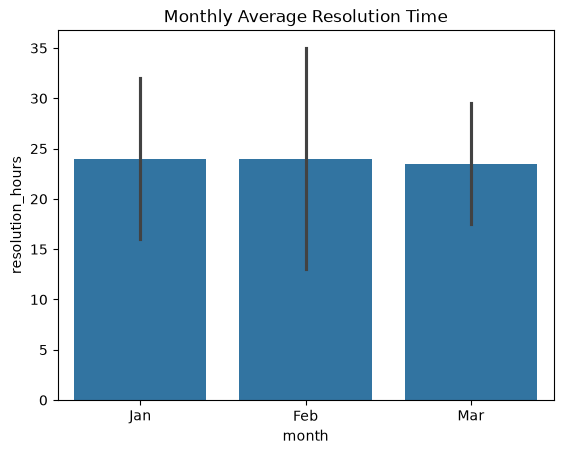

In [38]:
sns.barplot(x=merged_df['month'] , y=merged_df['resolution_hours'])
plt.title("Monthly Average Resolution Time")
plt.show()

In [44]:
#  Create outputs folder
os.makedirs("outputs", exist_ok=True)

#  Export clean merged DataFrame
merged_df.to_csv("outputs/clean_data.csv",index=False)
 
# Export department summary
department_summary.to_csv("outputs/python_summary.csv",index=False)